**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Import and Preprocess Dataset**

In [ ]:
df = pd.read_csv("/content/data.csv")
print("Original shape:", df.shape)
display(df.head())

Original shape: (18288, 3)


,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2


In [ ]:
#Parse Datetime correctly
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M')

In [ ]:
#Set Datetime as index, sort, drop ID
df = df.set_index('Datetime').sort_index()
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

In [ ]:
#Make sure Count is numeric
df['Count'] = pd.to_numeric(df['Count'], errors='coerce')

In [ ]:
#Handle any missing values
df['Count'] = df['Count'].ffill().bfill()

In [ ]:
# Basic stats to understand scale
print("\nCount statistics:")
display(df['Count'].describe())


Count statistics:


,Count
count,18288.000000
mean,138.958115
std,153.467461
min,2.000000
25%,22.000000
50%,84.000000
75%,210.000000
max,1244.000000


**Scale data & create sequences**

In [ ]:
value_col = 'Count'
values = df[[value_col]].values

scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

print("Total data points:", len(values_scaled))

def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 24
X, y = create_sequences(values_scaled, window_size=window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

Total data points: 18288
X shape: (18264, 24, 1)
y shape: (18264, 1)


**Time-based train / val / test split**

In [ ]:
train_ratio = 0.7
val_ratio   = 0.15

n_samples = len(X)
train_end = int(n_samples * train_ratio)
val_end   = int(n_samples * (train_ratio + val_ratio))

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (12784, 24, 1) (12784, 1)
Val:   (2740, 24, 1) (2740, 1)
Test:  (2740, 24, 1) (2740, 1)


**Build LSTM model**

In [ ]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train the model**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0018 - mae: 0.0279 - val_loss: 0.0028 - val_mae: 0.0378
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.8007e-04 - mae: 0.0157 - val_loss: 0.0023 - val_mae: 0.0336
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.7841e-04 - mae: 0.0145 - val_loss: 0.0017 - val_mae: 0.0294
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.9657e-04 - mae: 0.0135 - val_loss: 0.0015 - val_mae: 0.0271
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.4804e-04 - mae: 0.0129 - val_loss: 0.0013 - val_mae: 0.0258
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.1978e-04 - mae: 0.0126 - val_loss: 0.0012 - val_mae: 0.0251
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.9821e-04 - mae: 0.0122 - val_loss: 0.0012 - val_mae: 0.0248
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.9640e-04 - mae: 0.0123 - val_loss: 0.0011 - val_mae: 0.0243
Epoch 9/50
200/200 ━━━━━

**Evaluate & plot predictions**

Test MSE (scaled): 0.004093
Test MAE (scaled): 0.041852
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Test MSE (original units): 6313.4177
Test MAE (original units): 51.9800


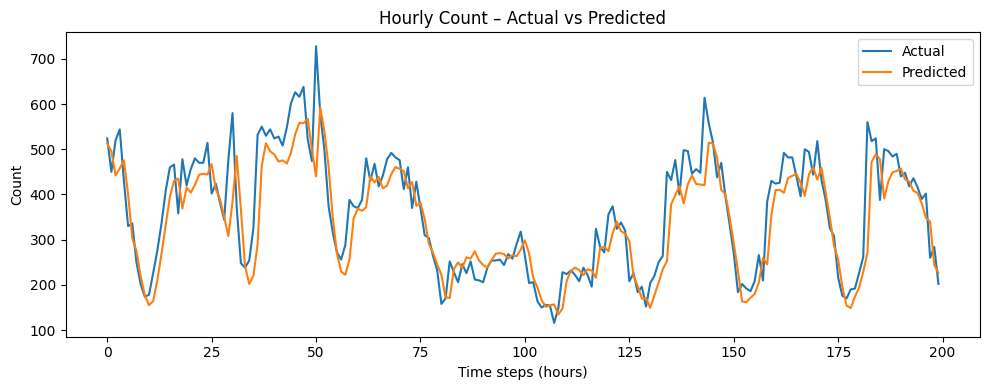

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE (scaled): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")

y_pred_scaled = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"\nTest MSE (original units): {mse:.4f}")
print(f"Test MAE (original units): {mae:.4f}")

plt.figure(figsize=(10, 4))
n_plot = min(200, len(y_test_inv))
plt.plot(y_test_inv[:n_plot], label='Actual')
plt.plot(y_pred_inv[:n_plot], label='Predicted')
plt.title('Hourly Count – Actual vs Predicted')
plt.xlabel('Time steps (hours)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Predict next hour from latest data**

In [ ]:
last_window = values_scaled[-window_size:]
last_window = np.expand_dims(last_window, axis=0)

next_pred_scaled = model.predict(last_window)
next_pred = scaler.inverse_transform(next_pred_scaled)[0, 0]

print("Predicted Count for NEXT hour:", next_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Count for NEXT hour: 480.9502
